In [44]:
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pickle
import os
import importlib

from src.data import load_data_excel, convert_numeric_columns
from src.features import encode_categorical_feature, get_simplified_names
from src import experiments
# Force reload to pick up latest changes
importlib.reload(experiments)
from src.experiments import (
    prepare_data_random_split, prepare_data_hide_one_per_class,
    prepare_data_hide_class, train_xgboost_models, get_hidden_products_info,
    train_xgboost_models_cv, leave_one_product_out_cv
)
from src.visu import plot_ml_results

# Load data
data = load_data_excel('../data/sources/Donnees_IA_2025.xlsx')

# Define variables - Only physicochemical features (chemical composition)
vars_expl = [
    "MS % brut", "PB % brut", "CB % brut", "MGR % brut", "MM % brut",
    "NDF % brut", "ADF % brut", "Lignine % brut", "Amidon % brut", "Sucres % brut"
]

vars_cibles = [
    "EB (kcal) kcal/kg brut", "ED porc croissance (kcal) kcal/kg brut",
    "EM porc croissance (kcal) kcal/kg brut", "EN porc croissance (kcal) kcal/kg brut",
    "EMAn coq (kcal) kcal/kg brut", "EMAn poulet (kcal) kcal/kg brut",
    "UFL 2018 par kg brut", "UFV 2018 par kg brut", "PDIA 2018 g/kg brut",
    "PDI 2018 g/kg brut", "BalProRu 2018 g/kg brut"
]

# Convert numeric columns
data = convert_numeric_columns(data, vars_expl + vars_cibles)

# Get simplified names
simplified_names = get_simplified_names()

# Create directories for results if not exist
os.makedirs('../results/pickle', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

print(f"Data loaded: {len(data)} observations")
print(f"Features: {len(vars_expl)} physicochemical variables")
print(f"Targets: {len(vars_cibles)} target variables")

Data loaded: 6376 observations
Features: 10 physicochemical variables
Targets: 11 target variables


## Leave One Product Out Cross-Validation (LOPO-CV) Analysis

### Evaluating Model Robustness to Unknown Products
Focus: **XGBoost with Physicochemical Features Only**

- **ID Baseline**: 5-Fold Cross-Validation (standard distribution)
- **OOD Test**: Leave One Product Out (holds one product per fold)
- Comparaion with Model_1_All_Chemical from pickle

In [23]:
# ID Baseline: 5-Fold Cross-Validation
print("\n" + "="*80)
print("BASELINE ID: 5-Fold Cross-Validation (In-Distribution)")
print("="*80)

summary_id_cv, metrics_id_cv, fold_scores_id_cv, details_id_cv, r2_global_folds_id = train_xgboost_models_cv(
    data[vars_expl],
    data[vars_cibles],
    vars_cibles,
    simplified_names,
    n_splits=5,
    random_state=42
)

print(f"\nR² Variance Weighted Mean: {metrics_id_cv['R2_variance_weighted_mean']:.4f}")
print(f"R² Variance Weighted Std: {metrics_id_cv['R2_variance_weighted_std']:.4f}")
print(f"R² Mean (across all targets): {metrics_id_cv['R2_mean']:.4f}")
print(f"R² Std: {metrics_id_cv['R2_std']:.4f}")

print("\nPer-Target Results (5-Fold CV):")
print(summary_id_cv.to_string(index=False))

print(f"\n✓ Global R² per fold (n={len(r2_global_folds_id)}):")
print(f"  {[f'{r2:.4f}' for r2 in r2_global_folds_id]}")


BASELINE ID: 5-Fold Cross-Validation (In-Distribution)

R² Variance Weighted Mean: 0.9904
R² Variance Weighted Std: 0.0010
R² Mean (across all targets): 0.9903
R² Std: 0.0024

Per-Target Results (5-Fold CV):
Variable cible  R2_mean   R2_std  MAE_mean  MAE_std  RMSE_mean  RMSE_std
            EB 0.992541 0.001112 31.615860 0.784282  53.885761  2.407744
       ED porc 0.988921 0.002087 47.883861 1.716752  87.769688  7.929075
       EM porc 0.990108 0.001479 44.952786 1.858891  79.858209  5.987689
       EN porc 0.993222 0.000487 33.917581 1.169825  58.177821  2.528183
      EMAn coq 0.990005 0.000929 48.776328 0.784263  81.427375  2.199241
   EMAn poulet 0.989106 0.001166 49.604993 1.104952  82.478343  3.619159
           UFL 0.987006 0.002436  0.018479 0.001073   0.032718  0.002946
           UFV 0.986243 0.001749  0.021056 0.001018   0.038161  0.002420
          PDIA 0.991156 0.003212  2.819072 0.231377   7.508407  1.525067
           PDI 0.991875 0.002891  2.801264 0.220033   7.10020

In [42]:
# OOD Test: Leave One Product Out Cross-Validation
print("\n" + "="*80)
print("OOD TEST: Leave One Product Out Cross-Validation (Out-Of-Distribution)")
print("="*80)

summary_lopo, metrics_lopo, fold_scores_lopo, details_lopo, r2_global_folds_lopo = leave_one_product_out_cv(
    data,
    vars_expl,
    vars_cibles,
    simplified_names,
    product_col='Nom',
    random_state=42
)

print(f"\nR² Variance Weighted Mean: {metrics_lopo['R2_variance_weighted_mean']:.4f}")
print(f"R² Variance Weighted Std: {metrics_lopo['R2_variance_weighted_std']:.4f}")
print(f"R² Mean (across all targets): {metrics_lopo['R2_mean']:.4f}")
print(f"R² Std: {metrics_lopo['R2_std']:.4f}")

print("\nPer-Target Results (LOPO-CV):")
print(summary_lopo.to_string(index=False))

# Convert details_lopo to DataFrame for easier analysis
lopo_df = pd.DataFrame(details_lopo)
print(f"\nLOPO Details: {len(lopo_df)} fold-target combinations")
print(f"Unique products tested: {lopo_df['Product'].nunique()}")

print(f"\n✓ Global R² per product (n={len(r2_global_folds_lopo)}):")
for i, (product, r2) in enumerate(zip(lopo_df['Product'].unique(), r2_global_folds_lopo)):
    print(f"  {i+1}. {product}: {r2:.4f}")


OOD TEST: Leave One Product Out Cross-Validation (Out-Of-Distribution)


TypeError: list indices must be integers or slices, not str

In [4]:
# Load baseline model from pickle for comparison
print("\n" + "="*80)
print("COMPARISON WITH MODEL_1_ALL_CHEMICAL (BASELINE FROM PICKLE)")
print("="*80)

pickle_path = '../results/pickle/model1_all_chemicals_cv.pkl'
if os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as f:
        model1_baseline = pickle.load(f)
    
    print(f"\nLoaded from: {pickle_path}")
    print(f"Content keys: {list(model1_baseline.keys())}")
    
    # Extract metrics from baseline
    if 'metrics' in model1_baseline:
        baseline_metrics = model1_baseline['metrics']
        print(f"\nBaseline Model_1_All_Chemical R² Metrics:")
        print(f"  R² Variance Weighted Mean: {baseline_metrics.get('R2_variance_weighted_mean', 'N/A'):.4f}" 
              if isinstance(baseline_metrics.get('R2_variance_weighted_mean'), (int, float)) else f"  R² Variance Weighted: {baseline_metrics.get('R2_variance_weighted', 'N/A'):.4f}")
else:
    print(f"⚠ Pickle file not found: {pickle_path}")
    baseline_metrics = None


COMPARISON WITH MODEL_1_ALL_CHEMICAL (BASELINE FROM PICKLE)

Loaded from: ../results/pickle/model1_all_chemicals_cv.pkl
Content keys: ['summary', 'metrics', 'fold_scores', 'details']

Baseline Model_1_All_Chemical R² Metrics:
  R² Variance Weighted Mean: 0.9904


/tmp/ipykernel_19397/3673077753.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box,


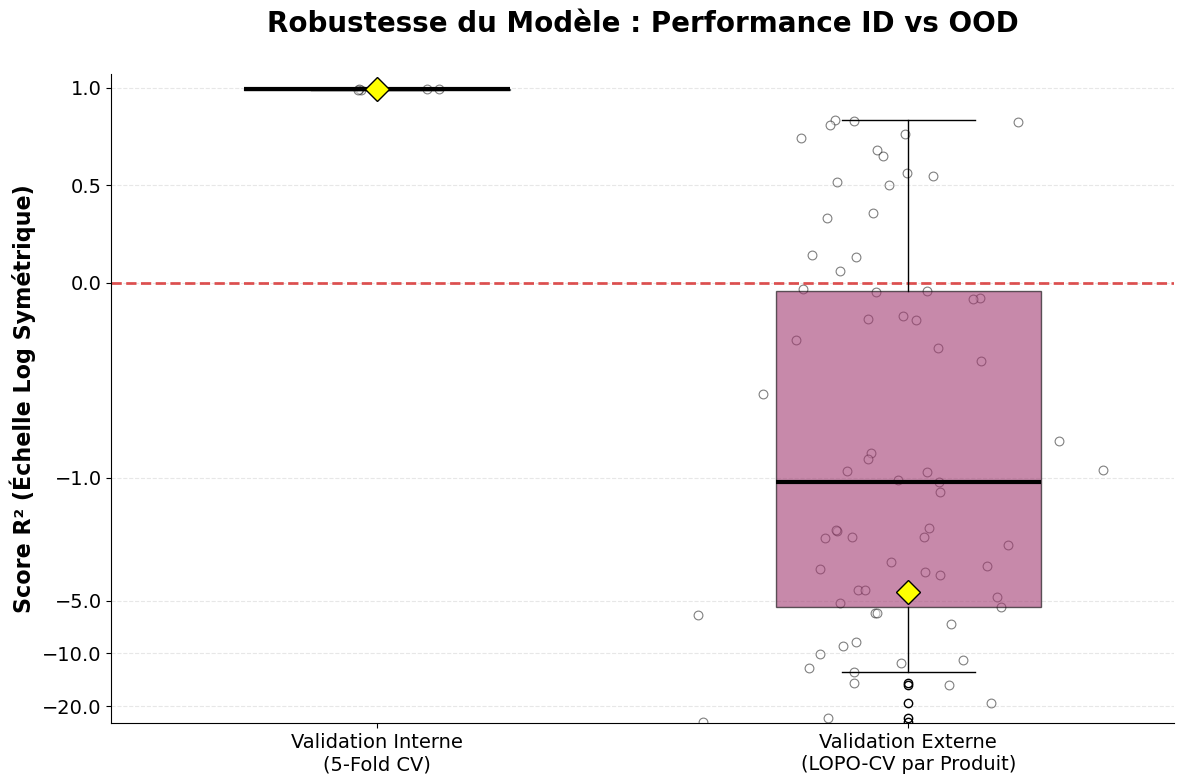

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Configuration du style pour présentation (fond blanc, polices larges)
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)

# 1. Ligne de référence R² = 0 (Modèle naïf)
ax.axhline(0, color='#D62828', linestyle='--', linewidth=2, alpha=0.8, label='Seuil de référence (R²=0)')

# Préparation des données
data_for_box = [id_r2_per_fold, lopo_r2_per_fold]

# 2. Échelle Logarithmique Symétrique (essentiel pour voir 0.9 et -20 en même temps)
ax.set_yscale('symlog', linthresh=1.0)

# Création du Boxplot
bp = ax.boxplot(data_for_box,
                 labels=['Validation Interne\n(5-Fold CV)', 'Validation Externe\n(LOPO-CV par Produit)'],
                 patch_artist=True, widths=0.5, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='yellow', markersize=12, markeredgecolor='black', label='Moyenne'),
                 medianprops=dict(color='black', linewidth=3))

# Couleurs distinctes et élégantes
colors = ['#2E86AB', '#A23B72'] # Bleu profond et bordeaux
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 3. Points individuels (Jitter)
for i, data in enumerate(data_for_box):
    spread = 0.05 if i == 0 else 0.15 
    x_jitter = np.random.normal(i + 1, spread, size=len(data))
    ax.scatter(x_jitter, data, alpha=0.5, s=40, color='white', edgecolors='black', linewidth=0.8)

# 4. Formatage de l'axe Y (Français & Lisibilité)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_yticks([1, 0.5, 0, -1, -5, -10, -20])
ax.tick_params(axis='both', which='major', labelsize=14)

# # 5. Encadré de statistiques traduit
# stats_text = f"""RÉSUMÉ STATISTIQUE :
# Moyenne ID :   {id_mean:.3f}
# Moyenne OOD :  {lopo_mean:.3f}
# Score Min (OOD) : {np.min(lopo_r2_per_fold):.1f}
# N (Produits) :  {len(lopo_r2_per_fold)}"""

# # Positionné en haut à gauche pour la diapo
# ax.text(0.03, 0.96, stats_text, transform=ax.transAxes,
#         fontsize=12, verticalalignment='top', horizontalalignment='left',
#         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'),
#         family='monospace', fontweight='bold')

# Titres et Labels en Français
ax.set_ylabel('Score R² (Échelle Log Symétrique)', fontsize=16, fontweight='bold')
ax.set_title('Robustesse du Modèle : Performance ID vs OOD', fontsize=20, fontweight='bold', pad=30)

# Grille épurée
ax.grid(axis='y', which='both', alpha=0.3, linestyle='--')
ax.set_ylim([-25, 1.2]) # Un peu d'espace en haut pour les labels

# Suppression des bordures inutiles pour un look moderne
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

SECTION DRAFT

## Out-Of-Distribution (OOD) Robustness Testing

Test model generalization by hiding products/classes during training and evaluating on held-out data.

### Baseline: In-Distribution Random Split (IID)

In [2]:
# IID Baseline
X_train_iid, X_test_iid, y_train_iid, y_test_iid = prepare_data_random_split(
    data, vars_expl, vars_cibles, test_size=0.2, random_state=42
)

results_iid, metrics_iid, models_iid = train_xgboost_models(
    X_train_iid, X_test_iid, y_train_iid, y_test_iid,
    vars_cibles, simplified_names, random_state=42
)

print("\n" + "="*80)
print("BASELINE: In-Distribution (IID) Random Split")
print("="*80)
print(f"Train: {len(X_train_iid)}, Test: {len(X_test_iid)}")
print(f"R² variance weighted: {metrics_iid['R2_variance_weighted']:.4f}")
print(f"R² uniform: {metrics_iid['R2_uniform']:.4f}")


BASELINE: In-Distribution (IID) Random Split
Train: 5100, Test: 1276
R² variance weighted: 0.9899
R² uniform: 0.9903


### OOD Scenario 1: Hide 1 Random Product Per Class

In [3]:
# OOD Scenario 1: Hide 1 product per class
X_train_ood1, X_test_ood1, y_train_ood1, y_test_ood1, classe_test_ood1, nom_test_ood1 = \
    prepare_data_hide_one_per_class(data, vars_expl, vars_cibles, 'Classe', random_state=42)

results_ood1, metrics_ood1, models_ood1 = train_xgboost_models(
    X_train_ood1, X_test_ood1, y_train_ood1, y_test_ood1,
    vars_cibles, simplified_names, random_state=42
)

hidden_products = get_hidden_products_info(classe_test_ood1, nom_test_ood1)

print("\n" + "="*80)
print("OOD SCENARIO 1: Hide 1 Random Product Per Class")
print("="*80)
print(f"Train: {len(X_train_ood1)}, Test: {len(X_test_ood1)}")
print(f"R² variance weighted: {metrics_ood1['R2_variance_weighted']:.4f}")
print(f"\nPerformance drop vs IID: {metrics_ood1['R2_variance_weighted'] - metrics_iid['R2_variance_weighted']:+.4f}")
print("\nHidden products used for testing:")
print(hidden_products.to_string(index=False))


OOD SCENARIO 1: Hide 1 Random Product Per Class
Train: 5160, Test: 1216
R² variance weighted: 0.7695

Performance drop vs IID: -0.2204

Hidden products used for testing:
                                Classe                                          Nom
                              Céréales                                    Triticale
              Autres produits végétaux                  Farine de gousse de caroube
        Autres coproduits des céréales                    Coproduits de biscuiterie
                    Coproduits du maïs                               Germes de maïs
                     Coproduits du blé               Remoulage de blé tendre (tous)
        Farines et solubles de poisson                   Farine de poisson (toutes)
       Coproduits d'animaux terrestres                    Farine de viande (toutes)
Graines protéagineuses et oléagineuses                     Pois chiche, type Kabuli
                 Fourrages déshydratés                                Pai

### OOD Scenario 2: Hide Entire Class

In [4]:
# OOD Scenario 2: Hide entire class
X_train_ood2, X_test_ood2, y_train_ood2, y_test_ood2, classe_hidden = \
    prepare_data_hide_class(data, vars_expl, vars_cibles, 'Classe', random_state=42)

results_ood2, metrics_ood2, models_ood2 = train_xgboost_models(
    X_train_ood2, X_test_ood2, y_train_ood2, y_test_ood2,
    vars_cibles, simplified_names, random_state=42
)

print("\n" + "="*80)
print("OOD SCENARIO 2: Hide Entire Class")
print("="*80)
print(f"Hidden class: {classe_hidden}")
print(f"Train: {len(X_train_ood2)}, Test: {len(X_test_ood2)}")
print(f"R² variance weighted: {metrics_ood2['R2_variance_weighted']:.4f}")
print(f"\nPerformance drop vs IID: {metrics_ood2['R2_variance_weighted'] - metrics_iid['R2_variance_weighted']:+.4f}")
print(f"Performance drop vs OOD1: {metrics_ood2['R2_variance_weighted'] - metrics_ood1['R2_variance_weighted']:+.4f}")


OOD SCENARIO 2: Hide Entire Class
Hidden class: Céréales
Train: 5627, Test: 749
R² variance weighted: 0.6505

Performance drop vs IID: -0.3394
Performance drop vs OOD1: -0.1190


### OOD Performance Summary & Visualization

In [5]:
scenarios_data = [
    {"Scenario": "IID Baseline", "metrics": metrics_iid, "size": len(X_test_iid)},
    {"Scenario": "OOD: Hide 1 Product", "metrics": metrics_ood1, "size": len(X_test_ood1)},
    {"Scenario": "OOD: Hide Class", "metrics": metrics_ood2, "size": len(X_test_ood2)},
]

ood_comparison = pd.DataFrame([
    {
        'Scenario': s['Scenario'],
        'Test Size': s['size'],
        'R² Variance Weighted': s['metrics']['R2_variance_weighted'],
        'Performance Drop': s['metrics']['R2_variance_weighted'] - metrics_iid['R2_variance_weighted']
    } 
    for s in scenarios_data
])


OOD PERFORMANCE SUMMARY TABLE
           Scenario  Test Size  R² Variance Weighted  Performance Drop
       IID Baseline       1276                0.9899            0.0000
OOD: Hide 1 Product       1216                0.7695           -0.2204
    OOD: Hide Class        749                0.6505           -0.3394


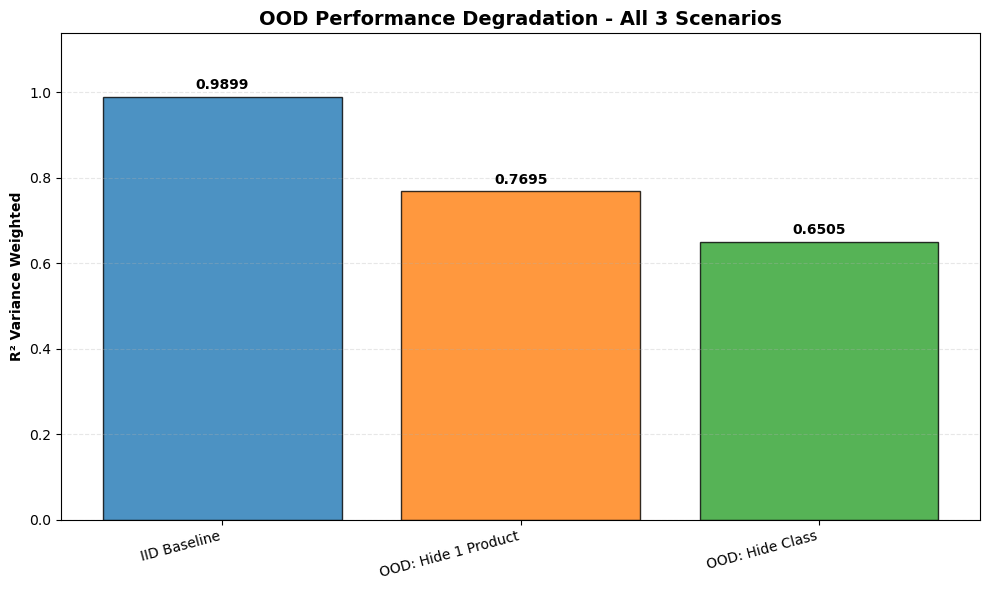

In [14]:
# Display OOD comparison
print("\n" + "="*80)
print("OOD PERFORMANCE SUMMARY TABLE")
print("="*80)
print(ood_comparison.to_string(index=False))

# OOD comparison visualization
fig = plot_ml_results(
    ood_comparison,
    x_col='Scenario',
    y_col='R² Variance Weighted',
    title='OOD Performance Degradation - All 3 Scenarios',
    figsize=(10, 6)
)
plt.show()

cross validation à faire

### OOD Scenario 3: Hide Specific Class (Parametric)
#### 'Autres produits végétaux'

In [7]:
# OOD Scenario 3: Hide specific class (parametric)
# User can specify which class to hide
available_classes = data['Classe'].unique()
print(f"Available classes: {list(available_classes)}")

# Choose a class to hide (different from Scenario 2)
class_to_hide_param = available_classes[1] if len(available_classes) > 1 else available_classes[0]

X_train_ood3, X_test_ood3, y_train_ood3, y_test_ood3, classe_hidden_param = \
    prepare_data_hide_class(data, vars_expl, vars_cibles, 'Classe', 
                           class_to_hide=class_to_hide_param, random_state=42)

results_ood3, metrics_ood3, models_ood3 = train_xgboost_models(
    X_train_ood3, X_test_ood3, y_train_ood3, y_test_ood3,
    vars_cibles, simplified_names, random_state=42
)

print("\n" + "="*80)
print(f"OOD SCENARIO 3: Hide Specific Class ('{classe_hidden_param}')")
print("="*80)
print(f"Train: {len(X_train_ood3)}, Test: {len(X_test_ood3)}")
print(f"R² variance weighted: {metrics_ood3['R2_variance_weighted']:.4f}")

Available classes: ['Céréales', 'Autres produits végétaux', 'Autres coproduits des céréales', 'Coproduits du maïs', 'Coproduits du blé', 'Farines et solubles de poisson', "Coproduits d'animaux terrestres", 'Graines protéagineuses et oléagineuses', 'Fourrages déshydratés', 'Amidon, racines et tubercules', 'Coproduits de fruits et légumes', "Tourteaux d'oléagineux", 'Coproduits du riz', 'Mélasses et vinasses', 'Produits laitiers']

OOD SCENARIO 3: Hide Specific Class ('Autres produits végétaux')
Train: 5936, Test: 440
R² variance weighted: 0.8197


#### 'Graines protéagineuses et oléagineuses'

In [17]:
# OOD Scenario 3: Hide specific class (parametric)
# User can specify which class to hide
available_classes = data['Classe'].unique()
print(f"Available classes: {list(available_classes)}")

# Choose a class to hide (different from Scenario 2)
class_to_hide_param = available_classes[7] if len(available_classes) > 1 else available_classes[0]

X_train_ood3, X_test_ood3, y_train_ood3, y_test_ood3, classe_hidden_param = \
    prepare_data_hide_class(data, vars_expl, vars_cibles, 'Classe', 
                           class_to_hide=class_to_hide_param, random_state=42)

results_ood3, metrics_ood3, models_ood3 = train_xgboost_models(
    X_train_ood3, X_test_ood3, y_train_ood3, y_test_ood3,
    vars_cibles, simplified_names, random_state=42
)

print("\n" + "="*80)
print(f"OOD SCENARIO 3: Hide Specific Class ('{classe_hidden_param}')")
print("="*80)
print(f"Train: {len(X_train_ood3)}, Test: {len(X_test_ood3)}")
print(f"R² variance weighted: {metrics_ood3['R2_variance_weighted']:.4f}")

Available classes: ['Céréales', 'Autres produits végétaux', 'Autres coproduits des céréales', 'Coproduits du maïs', 'Coproduits du blé', 'Farines et solubles de poisson', "Coproduits d'animaux terrestres", 'Graines protéagineuses et oléagineuses', 'Fourrages déshydratés', 'Amidon, racines et tubercules', 'Coproduits de fruits et légumes', "Tourteaux d'oléagineux", 'Coproduits du riz', 'Mélasses et vinasses', 'Produits laitiers']

OOD SCENARIO 3: Hide Specific Class ('Graines protéagineuses et oléagineuses')
Train: 5719, Test: 657
R² variance weighted: 0.5025


/home/alan/projects/projet_fil_rouge/Clean_repo/notebooks/../src/visu.py:482: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


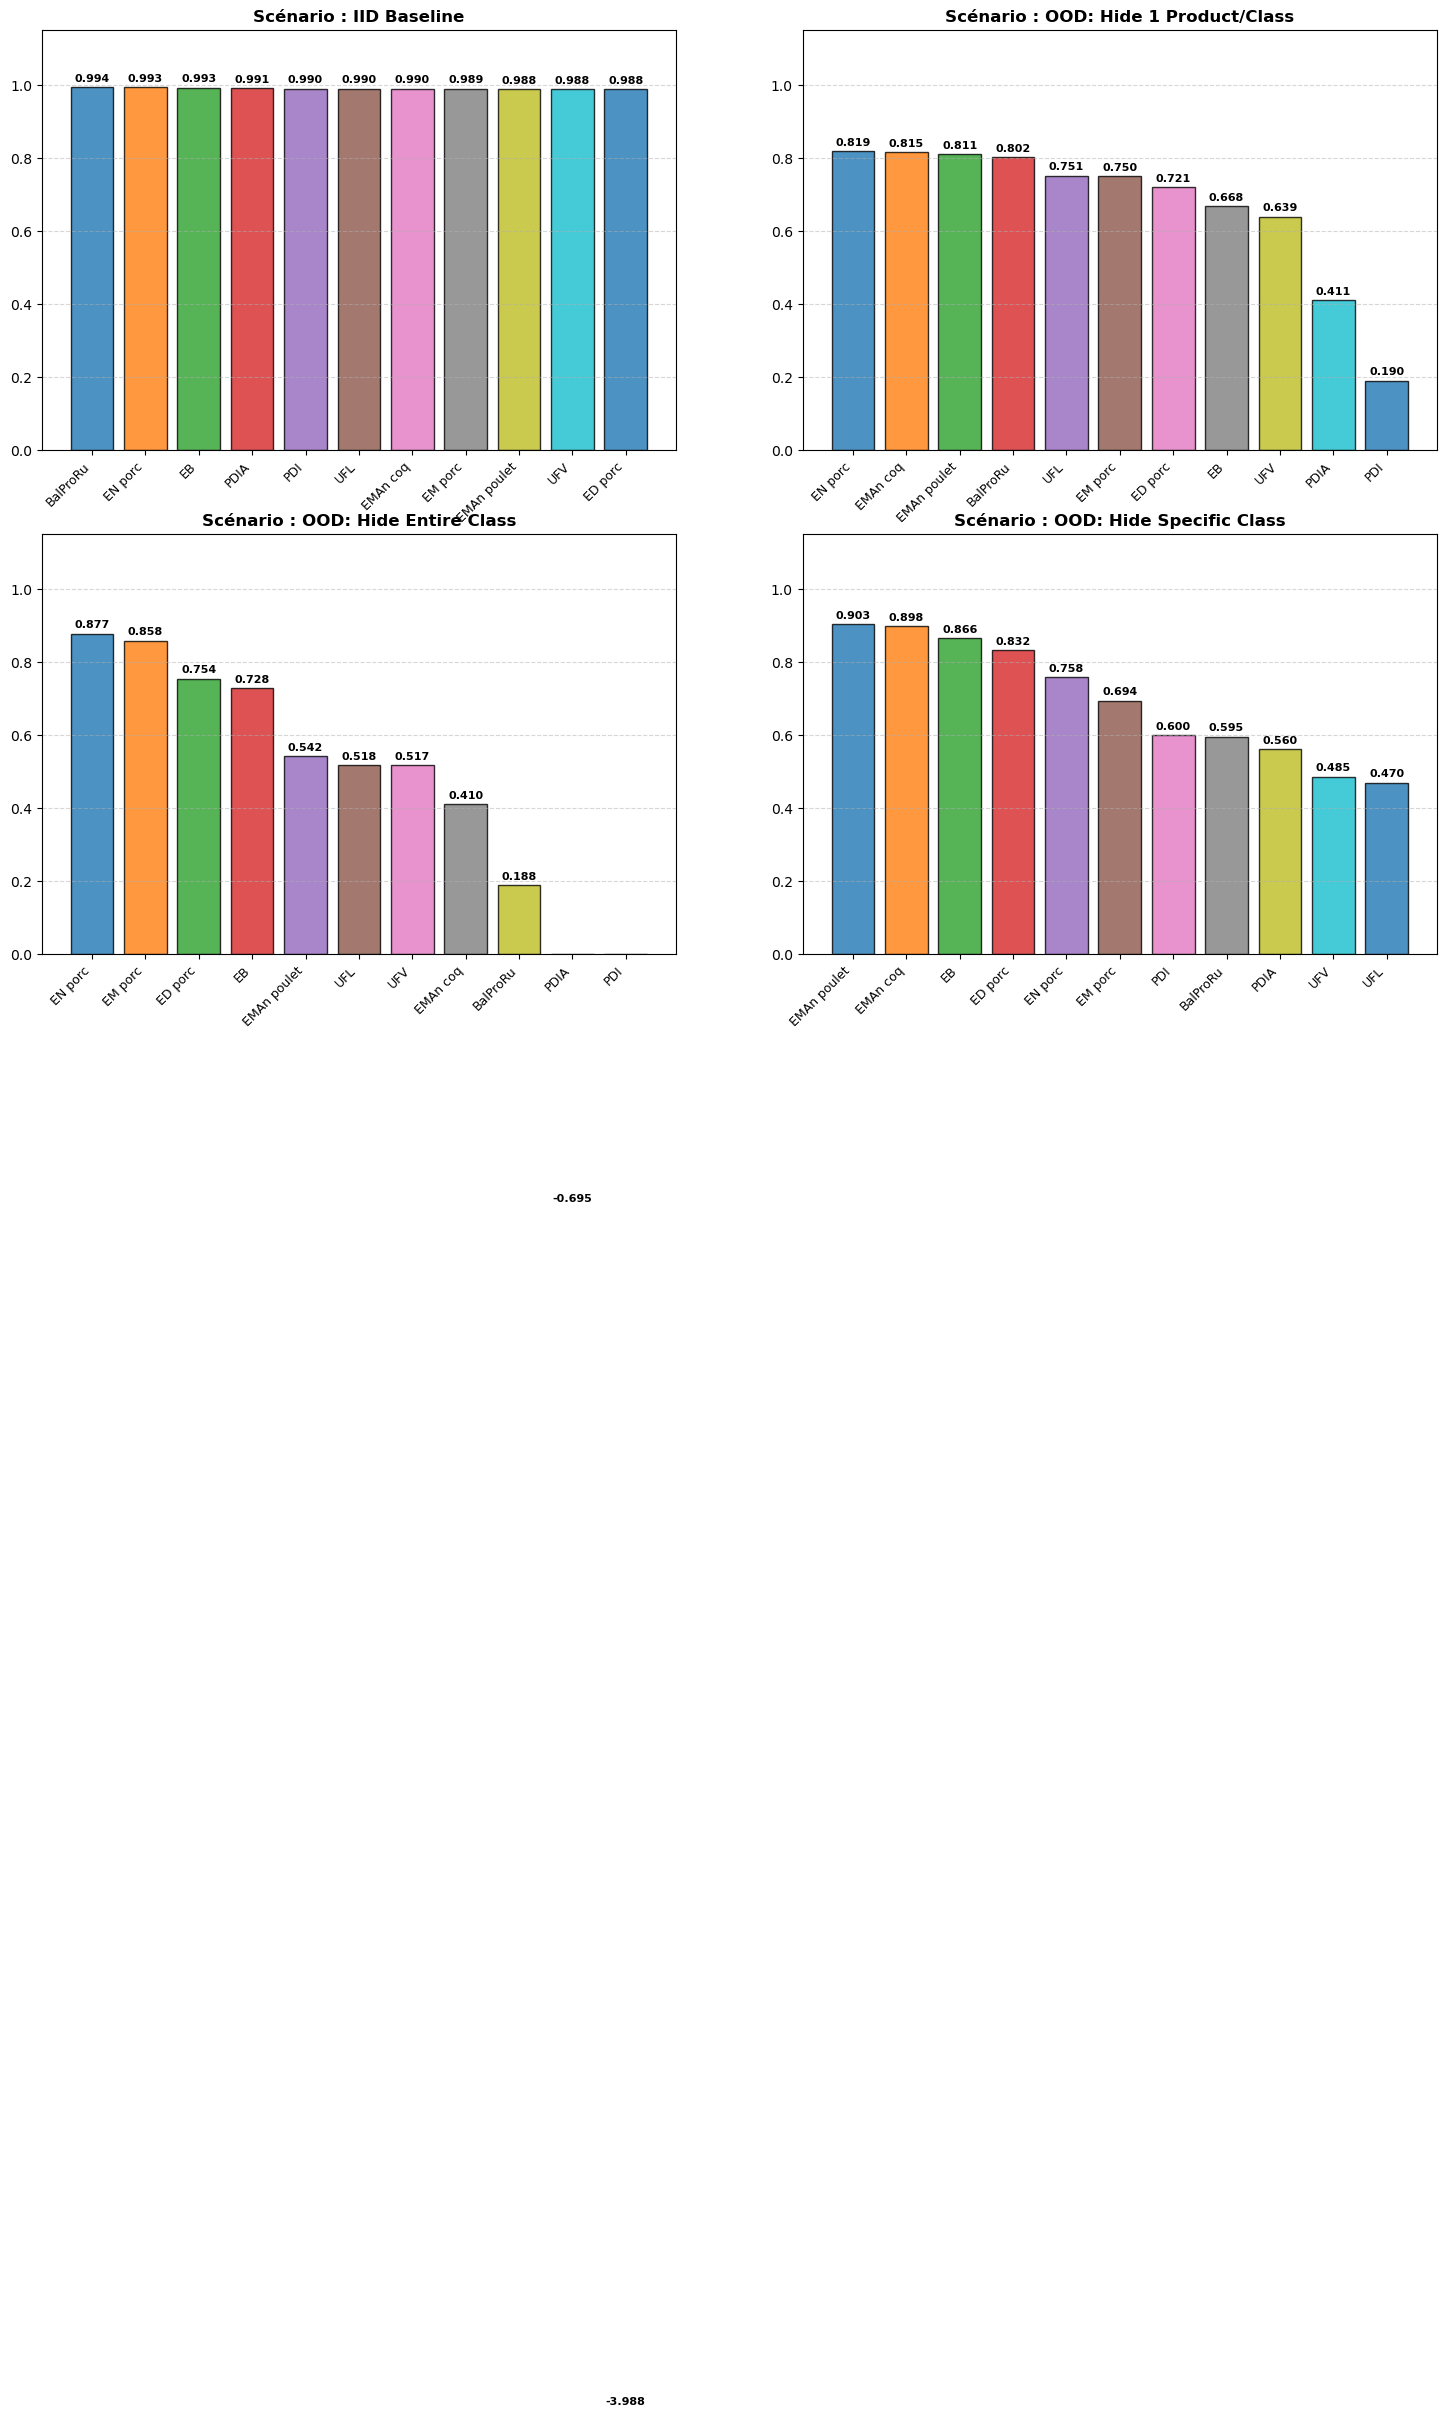

In [16]:
# Grid of R² by target variable for all OOD scenarios
all_ood_results = {
    'IID Baseline': results_iid,
    'OOD: Hide 1 Product/Class': results_ood1,
    'OOD: Hide Entire Class': results_ood2,
    'OOD: Hide Specific Class': results_ood3
}

fig = plot_ml_results(
    all_ood_results,
    y_col='R2',
    title='R² per Target Variable - All OOD Scenarios',
    figsize=(18, 12)
)
plt.show()